# Imports

In [1]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.SR_models import SR_go_ww
from ageing_packages.utils import sr_utils as utils
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib as mpl

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger


import pandas as pd
import sys, os, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
import thresholds_functions as th
mpl.rcParams['pdf.fonttype'] = 42  # Ensures TrueType fonts, which stay as text


# go with winners sim

In [30]:
import numpy as np
from scipy.interpolate import interp1d

import model_param_calibrations as mcal

n_sim = 20000
factor = 1.5

danish_dict = mcal.sr_denmark_dict.copy()
danish_Xc_std = mcal.sr_calibrations['denmark']['Xc_std']

# Adjust Xc for the given factor
danish_dict['Xc'] = 0.85 * factor * danish_dict['Xc']
danish_dict['eta'] = danish_dict['eta']

# Create parameter distribution as in your calibrations
danish_param_dist = utils.create_param_distribution_dict(
    params_dict=danish_dict, params='Xc', std=danish_Xc_std,
    n=n_sim, family='None', dist_type='gaussian'
)

# Run the go-with-winners simulation
sim = utils.create_go_ww_simulation(
    params_dict=danish_param_dist, n=n_sim, tmin=0, tmax=140,
    x0=1e-6, dt=0.005, units='years', calc_pdf=False, print_out=True
)



Heterogeneous mode: 50 parameter groups
  Group sizes: min=400, max=400, mean=400.0
  Varying parameters: ['Xc']
Pruned Group 0 at t=137.705


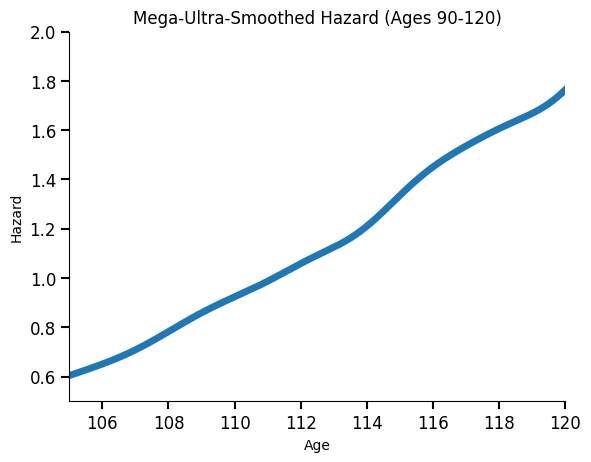

In [82]:
from scipy.ndimage import gaussian_filter1d

# Focus on ages 90 to 120 (or more, as requested)
age_min, age_max = 30, 150
mask = (sim.tspan >= age_min) & (sim.tspan <= age_max)
ages = sim.tspan[mask]
hazard = sim.hazard[mask]

# Extreme smoothing: massively increase window size
window_size = 1000  # even bigger smoothing window
sigma = window_size / 5

hazard_smoothed = gaussian_filter1d(hazard, sigma=sigma, mode='nearest')

plt.plot(ages, hazard_smoothed, linewidth=5)
plt.xlim(105,120)
plt.ylim(0.5, 2)
plt.xlabel('Age')
plt.ylabel('Hazard')
plt.title('Mega-Ultra-Smoothed Hazard (Ages 90-120)')
plt.show()


In [40]:
def plot_hmd_median_lifespan(ax, country, year=2020, n_sim=1000, ci=0.95, only_both=False, **plot_kwargs):
    import pandas as pd, numpy as np, os
    cc = {'fra': 'France', 'jpn': 'Japan', 'swe': 'Sweden', 'esp': 'Spain', 'ita': 'Italy', 'dan': 'Denmark'}
    country_up = country.upper()
    home = '/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/datasets/HMD_datasets/'
    pref = os.path.join(home, country_up, 'STATS')
    # Updated to fix FutureWarning: use sep='\s+' instead of delim_whitespace
    deaths = pd.read_csv(f"{pref}/Deaths_1x1.txt", sep=r'\s+', skiprows=2)
    expos = pd.read_csv(f"{pref}/Exposures_1x1.txt", sep=r'\s+', skiprows=2)
    ca = lambda x: 110 if str(x).strip() == '110+' else int(x)
    deaths['A'] = deaths.Age.map(ca)
    expos['A'] = expos.Age.map(ca)
    d = pd.merge(deaths[deaths.Year == year][['A', 'Total', 'Female', 'Male']],
                 expos[expos.Year == year][['A', 'Total', 'Female', 'Male']], on='A', suffixes=('_D', '_E')).sort_values('A')
    ta = np.arange(90, 109)
    sexes = ['Total', 'Female', 'Male']

    def medians(qx, ages, starts):
        meds = np.full_like(starts, np.nan, dtype=np.float64)
        for i, s in enumerate(starts):
            ix = ages >= s
            px = 1 - qx[ix]
            lx = np.insert(np.cumprod(px), 0, 1)
            j = np.argmax(lx <= 0.5)
            if lx[j] > 0.5 or j == 0: continue
            frac = (lx[j-1] - 0.5) / (lx[j-1] - lx[j])
            meds[i] = (s + j - 1) + frac
        return meds

    np.random.seed(42)
    res = {}
    for sex in sexes:
        D, E = d[f'{sex}_D'].values, d[f'{sex}_E'].values
        a = d['A'].values
        sim = np.array([medians(1-np.exp(-np.random.poisson(D) / (E + 1e-9)), a, ta) for _ in range(n_sim)])
        p = [(1-ci)/2*100, (1+ci)/2*100]
        res[sex] = {
            'median': sim.mean(0),
            'l': np.percentile(sim, p[0], 0),
            'u': np.percentile(sim, p[1], 0)
        }

    if only_both:
        y = res['Total']['median']
        l = res['Total']['l']
        u = res['Total']['u']
        lbl = cc.get(country.lower(), country.upper())
        # All plot formatting controlled by plot_kwargs
        ax.plot(ta, y-ta, label=lbl, **plot_kwargs)
        ax.fill_between(ta, l-ta, u-ta,
                        color=plot_kwargs.get('color', plot_kwargs.get('c', 'k')),
                        alpha=plot_kwargs.get('alpha_fill', 0.2))
        ax.set(
            title=None,
            xlabel='Current Age',
            ylabel='Median Remaining Lifespan'
        )
        ax.legend()
    else:
        # For multiple sexes, will plot each one, default lines/colors/markers but allow override for each
        default_color = {'Total': 'k', 'Female': 'r', 'Male': 'b'}
        default_marker = {'Total': None, 'Female': None, 'Male': None}
        default_linestyle = {'Total': '-', 'Female': '--', 'Male': '-.'}
        for sex in sexes:
            y = res[sex]['median']
            l, u = res[sex]['l'], res[sex]['u']
            lbl = f"{sex} ({int(ci*100)}% CI)"
            # Compose default and overridden plot arguments for this line
            sex_kwargs = dict(
                color=plot_kwargs.get(f'{sex.lower()}_color', plot_kwargs.get('color', default_color[sex])),
                linestyle=plot_kwargs.get(f'{sex.lower()}_linestyle', plot_kwargs.get('linestyle', default_linestyle[sex])),
                marker=plot_kwargs.get(f'{sex.lower()}_marker', plot_kwargs.get('marker', default_marker[sex])),
                linewidth=plot_kwargs.get('linewidth', 2),
                label=lbl
            )
            # Remove marker key if None to avoid matplotlib error with marker=None
            if sex_kwargs['marker'] is None:
                del sex_kwargs['marker']
            ax.plot(ta, y-ta, **sex_kwargs)

            ax.fill_between(
                ta, l-ta, u-ta,
                color=sex_kwargs['color'],
                alpha=plot_kwargs.get('alpha_fill', 0.2)
            )
        ax.set(title=f'Median Remaining Lifespan vs Age\n{cc.get(country.lower(),country.upper())} {year}',
               xlabel='Current Age', ylabel='Median Remaining Lifespan')
        ax.grid(True, linestyle='--', linewidth=0.5)
        ax.legend()
    # Do NOT print or return anything. Just plot.


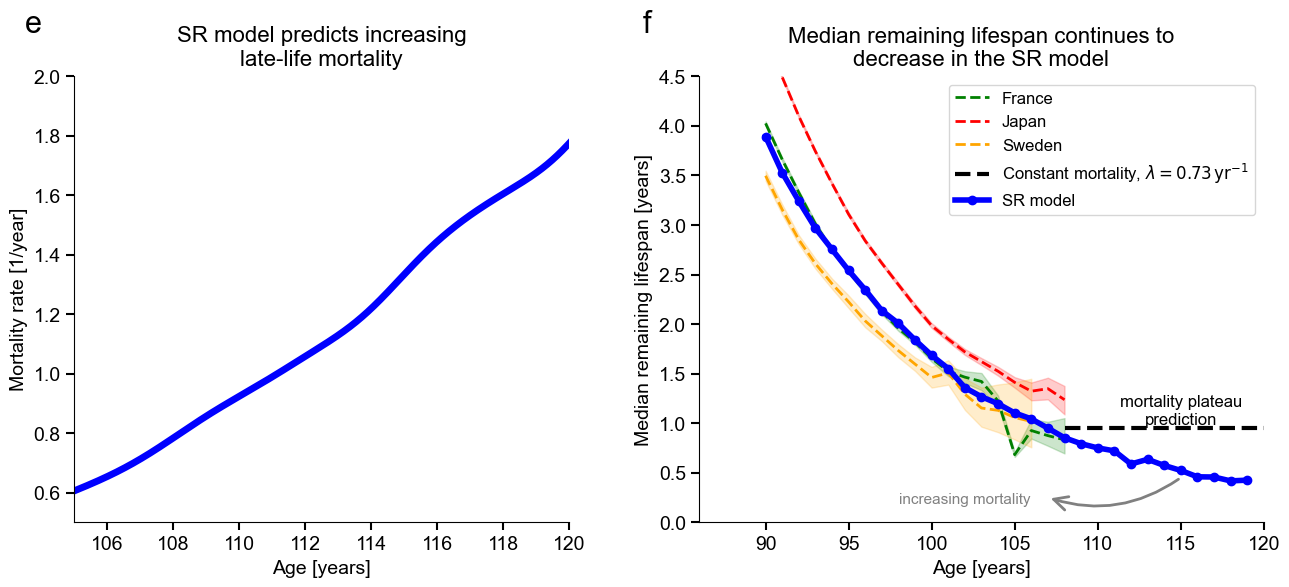

In [92]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.ndimage import gaussian_filter1d
from matplotlib import rcParams

# Set matplotlib globally to use Arial where possible
rcParams['font.family'] = 'Arial'

# Consistent fontsizes, labelsize
FS_LABEL = 14
FS_TITLE = 16
FS_LEGEND = 12
FS_PANEL = 22
FONTNAME = 'Arial'

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False, gridspec_kw={'width_ratios': [1,1.14]}) # Slightly wider right panel

# LEFT: Mortality hazard
ax0 = axes[0]
age_min, age_max = 30, 150
mask = (sim.tspan >= age_min) & (sim.tspan <= age_max)
ages = sim.tspan[mask]
hazard = sim.hazard[mask]

window_size = 1200
sigma = window_size / 5
hazard_smoothed = gaussian_filter1d(hazard, sigma=sigma, mode='nearest')

ax0.plot(ages, hazard_smoothed, linewidth=5, color='blue', label='Smoothed Hazard')
ax0.set_xlim(105, 120)
ax0.set_ylim(0.5, 2)
ax0.set_xlabel('Age [years]', fontsize=FS_LABEL, fontname=FONTNAME)
ax0.set_ylabel('Mortality rate [1/year]', fontsize=FS_LABEL, fontname=FONTNAME)
ax0.set_title('SR model predicts increasing\nlate-life mortality', fontsize=FS_TITLE, pad=8, fontname=FONTNAME)
ax0.text(-0.1, 1.15, "e", transform=ax0.transAxes, fontsize=FS_PANEL, va='top', ha='left', fontname=FONTNAME)
ax0.tick_params(axis='both', which='major', labelsize=FS_LABEL)
for tick in ax0.get_xticklabels() + ax0.get_yticklabels():
    tick.set_fontname(FONTNAME)

# RIGHT: mean remaining lifespan, model vs HMD
ax1 = axes[1]

# Prepare medians for SR model
cutoffs = np.arange(90, 120)
medians = []

for cutoff in cutoffs:
    idx = np.searchsorted(sim.tspan, cutoff)
    if idx >= len(sim.tspan) or sim.tspan[idx] < cutoff:
        medians.append(np.nan)
        continue
    t_c = sim.tspan[idx:]
    s_c = sim.survival[idx:]
    s_norm = s_c / s_c[0]
    median = np.nan
    below = np.where(s_norm <= 0.5)[0]
    if below.size > 0 and below[0] > 0:
        i = below[0]
        x0, x1 = t_c[i-1], t_c[i]
        y0, y1 = s_norm[i-1], s_norm[i]
        if y1 != y0:
            median = x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)
        else:
            median = x0
    medians.append(median - cutoff if not np.isnan(median) else np.nan)

plot_hmd_median_lifespan(ax1, country='FRA', only_both=True, color='green', linestyle='--', linewidth=2)
plot_hmd_median_lifespan(ax1, country='JPN', only_both=True, color='red', linestyle='--', linewidth=2)
plot_hmd_median_lifespan(ax1, country='SWE', only_both=True, color='orange', linestyle='--', linewidth=2)

lamda = 0.73
mort_plateau = np.log(2) / lamda
ax1.hlines(
    y=mort_plateau, xmin=108, xmax=125,
    colors='k',
    linestyles='dashed',
    label=r'Constant mortality, $\lambda = 0.73\,\mathrm{yr}^{-1}$',
    linewidth=3
)
ax1.text(115, 0.96, "mortality plateau\nprediction", fontsize=12, ha='center', va='bottom', fontname=FONTNAME)

ax1.plot(cutoffs, medians, marker='o', label='SR model', linewidth=4, color='blue')

# Curved arrow and annotation
arrow = FancyArrowPatch(
    (115, 0.45), (107, 0.25),
    connectionstyle="arc3,rad=-0.25",
    arrowstyle='->',
    mutation_scale=25,
    color="grey",
    linewidth=2,
    zorder=5
)
ax1.add_patch(arrow)
ax1.text(102, 0.3, "increasing mortality", ha="center", va="top", fontsize=11, color="grey", fontname=FONTNAME)

ax1.set_xlabel('Age [years]', fontsize=FS_LABEL, fontname=FONTNAME)
ax1.set_ylabel('Median remaining lifespan [years]', fontsize=FS_LABEL, fontname=FONTNAME)
ax1.set_xlim(86, 120)
ax1.set_ylim(0, 4.5)
ax1.set_title('Median remaining lifespan continues to\ndecrease in the SR model', fontsize=FS_TITLE, pad=8, fontname=FONTNAME)
ax1.tick_params(axis='both', which='major', labelsize=FS_LABEL)
for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontname(FONTNAME)
ax1.legend(prop={'family': FONTNAME, 'size': FS_LEGEND})
ax1.text(-0.1, 1.15, "f", transform=ax1.transAxes, fontsize=FS_PANEL, va='top', ha='left', fontname=FONTNAME)

fig.tight_layout(w_pad=3)
fig.savefig("Figures/plateu_fig.pdf", format="pdf")


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


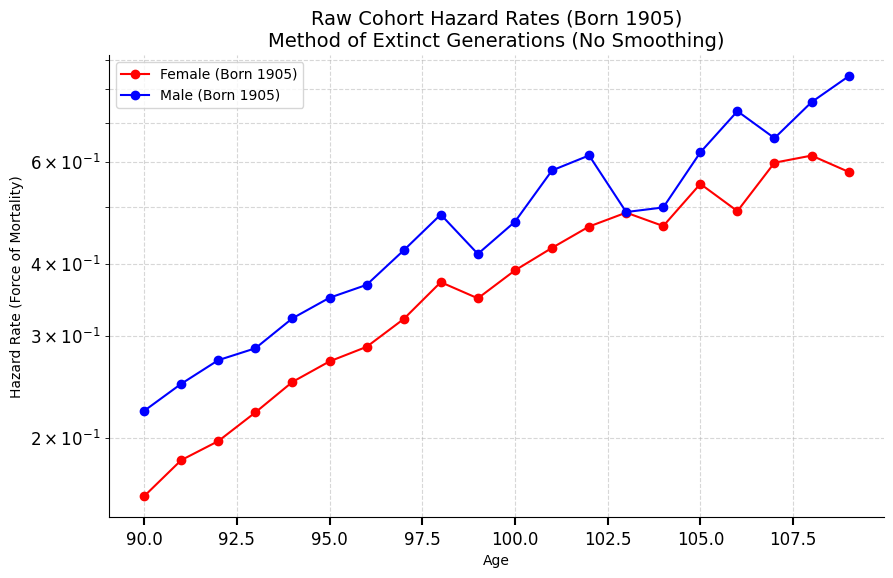

 Age  Pop_Total   Total  qx_Total  Hazard_Total
  90   93252.27 14925.0  0.160050      0.174413
  91   78327.27 14091.0  0.179899      0.198328
  92   64236.27 12384.0  0.192788      0.214169
  93   51852.27 10855.0  0.209345      0.234893
  94   40997.27  9520.0  0.232211      0.264240
  95   31477.27  7825.0  0.248592      0.285807
  96   23652.27  6155.0  0.260229      0.301414
  97   17497.27  5010.0  0.286330      0.337335
  98   12487.27  4021.0  0.322008      0.388620
  99    8466.27  2546.0  0.300723      0.357708


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import pandas as pd

home = '/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/datasets/HMD_datasets/'
country = 'FRA'  # Or 'JPN', 'SWE', etc. Define outside as needed
pref = os.path.join(home, country, 'STATS')
deaths = pd.read_csv(f"{pref}/Deaths_1x1.txt", sep=r'\s+', skiprows=2)

# 2. Configuration
COHORT_YEAR = 1905  # A cohort that is effectively extinct by 2020
START_AGE = 90
MAX_AGE_IN_DATA = 110 # Upper limit of file

def clean_age(x):
    return 110 if str(x).strip() == '110+' else int(x)

deaths['Age_Clean'] = deaths['Age'].apply(clean_age)

# 3. "Diagonalize" the Period Data to get Cohort Deaths
# We need D(age, year) where Year = Cohort + Age
cohort_deaths = []
ages = []

for age in range(START_AGE, MAX_AGE_IN_DATA + 1):
    year = COHORT_YEAR + age
    
    # Get deaths for this specific Age-Year intersection
    row = deaths[(deaths['Age_Clean'] == age) & (deaths['Year'] == year)]
    
    if not row.empty:
        # We sum Total, Female, Male
        d_total = row['Total'].values[0]
        d_female = row['Female'].values[0]
        d_male = row['Male'].values[0]
        
        cohort_deaths.append({
            'Age': age, 
            'Total': d_total, 
            'Female': d_female, 
            'Male': d_male
        })
        ages.append(age)

df_cohort = pd.DataFrame(cohort_deaths)

# 4. The Extinct Generation Calculation (Backwards Integration)
# Population at Age X = Sum of Deaths from Age X to End
results = []

# We reverse the dataframe to sum backwards, then reverse back
df_reversed = df_cohort.sort_values('Age', ascending=False)

for sex in ['Total', 'Female', 'Male']:
    # Cumulative Sum of deaths (backwards) gives Population at start of age interval
    # Shift(-1) because P(x) includes D(x)
    # Actually, P(x) is the survivors at age x. 
    # The people alive at 90 = Deaths(90) + Deaths(91) + ...
    # cumsum() on the reversed list does exactly this.
    
    deaths_col = df_reversed[sex].values
    pop_col = np.cumsum(deaths_col)
    
    # Add to dataframe (need to reverse back to match ascending Age)
    df_cohort[f'Pop_{sex}'] = pop_col[::-1]
    
    # Calculate Raw qx = D / P
    # Physics hazard rate: mx = -ln(1 - qx) or just qx for probability
    df_cohort[f'qx_{sex}'] = df_cohort[sex] / df_cohort[f'Pop_{sex}']
    
    # Calculate Log Hazard (ln(mx))
    # Approximation: mx ≈ qx / (1 - 0.5*qx)
    # ln_mx ≈ ln(qx) if qx is small, but at age 100 qx is large (~0.3-0.5)
    # Let's use exact conversion: Hazard H = -ln(1 - qx)
    df_cohort[f'Hazard_{sex}'] = -np.log(1 - df_cohort[f'qx_{sex}'])

# 5. Plotting the Raw Biological Hazard
plt.figure(figsize=(10, 6))

for sex, color in [('Female', 'red'), ('Male', 'blue')]:
    plt.plot(df_cohort['Age'], df_cohort[f'Hazard_{sex}'], 
             label=f'{sex} (Born {COHORT_YEAR})', color=color, marker='o')

plt.title(f'Raw Cohort Hazard Rates (Born {COHORT_YEAR})\nMethod of Extinct Generations (No Smoothing)', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Hazard Rate (Force of Mortality)')
plt.yscale('log') # Log scale is standard for Gompertz checking
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Print Table
print(df_cohort[['Age', 'Pop_Total', 'Total', 'qx_Total', 'Hazard_Total']].head(10).to_string(index=False))

Running Bootstrap (N=1000) for Cohort 1900...


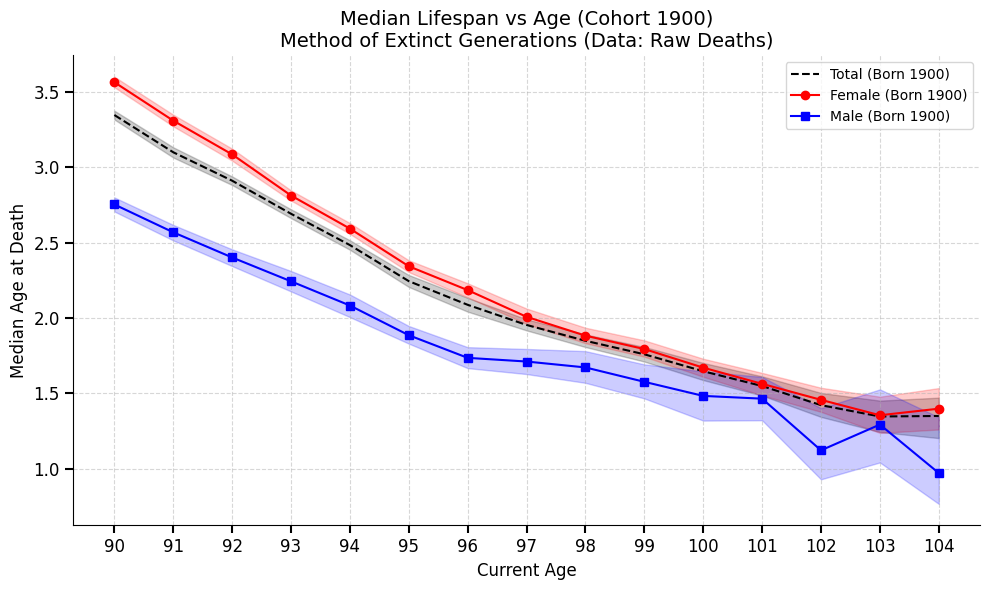

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Configuration
# ==========================================
COHORT_YEAR = 1900   # Must be effectively extinct (1905 + 115 = 2020)
START_AGE = 90
MAX_AGE_IN_DATA = 110
N_SIMULATIONS = 1000
CONFIDENCE_LEVEL = 0.95
np.random.seed(42)

# Load data

home = '/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/datasets/HMD_datasets/'
country = 'FRA'  # Or 'JPN', 'SWE', etc. Define outside as needed
pref = os.path.join(home, country, 'STATS')
deaths = pd.read_csv(f"{pref}/Deaths_1x1.txt", sep=r'\s+', skiprows=2)

# ==========================================
# 2. Data Preparation
# ==========================================
def clean_age(x):
    # Convert "110+" to 110 for numerical processing
    return 110 if str(x).strip() == '110+' else int(x)

deaths['Age_Clean'] = deaths['Age'].apply(clean_age)

# Extract Cohort Data (Diagonalization)
# We need D(age, year) where Year = Cohort + Age
cohort_deaths = []

for age in range(START_AGE, MAX_AGE_IN_DATA + 1):
    year = COHORT_YEAR + age
    
    # Get deaths for this specific Age-Year intersection
    row = deaths[(deaths['Age_Clean'] == age) & (deaths['Year'] == year)]
    
    if not row.empty:
        cohort_deaths.append({
            'Age': age, 
            'Total': row['Total'].values[0], 
            'Female': row['Female'].values[0], 
            'Male': row['Male'].values[0]
        })

df_cohort = pd.DataFrame(cohort_deaths)
ages_cohort = df_cohort['Age'].values

# ==========================================
# 3. Core Logic: Median from Extinct Cohort
# ==========================================
def calculate_median_from_deaths(deaths_array, ages_array, target_ages):
    """
    1. Reconstructs Population P(x) by summing deaths backwards.
    2. Calculates Median Lifespan for each target starting age.
    """
    # Reverse deaths to sum backwards
    d_rev = deaths_array[::-1]
    
    # Cumulative sum gives survivors P(x) at start of interval
    # (Assuming closed system, P(x) = sum(D from x to end))
    p_rev = np.cumsum(d_rev)
    
    # Reverse back to normal age order
    p_curve = p_rev[::-1]
    
    medians = []
    
    for start_age in target_ages:
        # Find index for start_age
        # We assume ages_array is sorted and continuous
        idx_start = np.where(ages_array == start_age)[0]
        
        if len(idx_start) == 0:
            medians.append(np.nan)
            continue
            
        idx_start = idx_start[0]
        
        # P_start is the population alive at start_age
        P_start = p_curve[idx_start]
        target_P = P_start / 2.0
        
        # Find where P(x) drops below target_P
        # We search in the subarray starting from idx_start
        sub_P = p_curve[idx_start:]
        sub_ages = ages_array[idx_start:]
        
        # Find first index where P <= target
        below_indices = np.where(sub_P <= target_P)[0]
        
        if len(below_indices) > 0:
            i = below_indices[0] # Index relative to start
            
            # If it happens at the very first step (unlikely unless P=0), handle it
            if i == 0:
                medians.append(sub_ages[0])
            else:
                # Linear Interpolation
                # P[i-1] > target
                # P[i] <= target
                P_upper = sub_P[i-1]
                P_lower = sub_P[i]
                age_upper = sub_ages[i-1]
                
                # Fraction of the year needed to drop to target
                # (Age moves from i-1 to i)
                if P_upper != P_lower:
                    fraction = (P_upper - target_P) / (P_upper - P_lower)
                else:
                    fraction = 0.5
                
                median_age = age_upper + fraction
                medians.append(median_age)
        else:
            # If we never drop below 50% (e.g., calculation ends at max age and P is still high)
            # For Extinct Cohort at 110, P drops to 0 effectively at end+1
            medians.append(np.nan)
            
    return np.array(medians)

# ==========================================
# 4. Monte Carlo Bootstrap
# ==========================================
target_start_ages = np.arange(START_AGE, 105) # 90 to 104
results = {}

print(f"Running Bootstrap (N={N_SIMULATIONS}) for Cohort {COHORT_YEAR}...")

for sex in ['Total', 'Female', 'Male']:
    D_obs = df_cohort[sex].values
    
    sim_medians = []
    
    for _ in range(N_SIMULATIONS):
        # Resample Deaths: Poisson(Observed)
        # This reflects the random variation in "who dies when"
        D_sim = np.random.poisson(D_obs)
        
        # Calculate Medians for this simulation
        meds = calculate_median_from_deaths(D_sim, ages_cohort, target_start_ages)
        sim_medians.append(meds)
    
    sim_medians = np.array(sim_medians)
    
    results[sex] = {
        'median': np.mean(sim_medians, axis=0),
        'lower': np.percentile(sim_medians, 2.5, axis=0),
        'upper': np.percentile(sim_medians, 97.5, axis=0)
    }

# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 6))

colors = {'Female': 'red', 'Male': 'blue', 'Total': 'black'}
markers = {'Female': 'o', 'Male': 's', 'Total': '--'}

for sex in ['Total', 'Female', 'Male']:
    x = target_start_ages
    y = results[sex]['median']
    y_low = results[sex]['lower']
    y_high = results[sex]['upper']
    
    label = f"{sex} (Born {COHORT_YEAR})"
    plt.plot(x, y-x, color=colors[sex], label=label, marker=markers[sex] if sex!='Total' else None, linestyle='-' if sex!='Total' else '--')
    plt.fill_between(x, y_low-x, y_high-x, color=colors[sex], alpha=0.2)

plt.title(f'Median Lifespan vs Age (Cohort {COHORT_YEAR})\nMethod of Extinct Generations (Data: Raw Deaths)', fontsize=14)
plt.xlabel('Current Age', fontsize=12)
plt.ylabel('Median Age at Death', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(target_start_ages)
plt.legend()
plt.tight_layout()
plt.show()
